In [1]:

import optuna
from dotenv import load_dotenv
load_dotenv()

True

# 1. BTTS

In [16]:
import sys
sys.path.append("..")

from models.feature_engineering import get_mask, round_to_step, get_return

In [3]:
target_col = "btts"

STUDY_NAME = f"{target_col}_aggregated_study"

study = optuna.load_study(
    study_name=STUDY_NAME,
    storage="sqlite:///../../data/output/greedy_model/aggregated_study.db",
)

print("Totale trial salvati:", len(study.trials))
print("Best assoluto:", study.best_trial.value, study.best_trial.params)

# se vuoi vedere tutti i best che avevi archiviato
for t in study.trials:
    print(t.number, t.value, t.params)

Totale trial salvati: 1
Best assoluto: 0.18433549566152796 {'goalNoGoal_chance_goalHome_use_min': False, 'goalNoGoal_chance_goalHome_use_max': True, 'goalNoGoal_chance_goalHome_min': 90.0, 'goalNoGoal_chance_goalHome_max': 100.0, 'goalNoGoal_chance_goalAway_use_min': False, 'goalNoGoal_chance_goalAway_use_max': True, 'goalNoGoal_chance_goalAway_min': 55.0, 'goalNoGoal_chance_goalAway_max': 70.0, 'goalNoGoal_comparison_affini_use_min': True, 'goalNoGoal_comparison_affini_use_max': True, 'goalNoGoal_comparison_affini_min': 6000, 'goalNoGoal_comparison_affini_max': 10000, 'underOver_chance_over15HT_use_min': False, 'underOver_chance_over15HT_use_max': True, 'underOver_chance_over15HT_min': 25, 'underOver_chance_over15HT_max': 50, 'underOver_comparison_affini_use_min': False, 'underOver_comparison_affini_use_max': True, 'underOver_comparison_affini_min': 12000, 'underOver_comparison_affini_max': 18000, 'evaluation_valScala_cat_idx': 9, 'evaluation_valMetrica_cat_idx': 203}
0 0.184335495661

In [4]:
from models.etl_pipeline_local import get_btts_table

In [5]:
df = get_btts_table()

In [17]:
feature_bins_map = study.best_trial.user_attrs["feature_bins_map"]
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x["goalNoGoal_quote_currentGG"]), axis=1).copy()


In [19]:
study.best_trial

FrozenTrial(number=0, state=<TrialState.COMPLETE: 1>, values=[0.18433549566152796], datetime_start=datetime.datetime(2026, 4, 1, 12, 36, 57, 690390), datetime_complete=datetime.datetime(2026, 4, 1, 12, 36, 57, 725341), params={'goalNoGoal_chance_goalHome_use_min': False, 'goalNoGoal_chance_goalHome_use_max': True, 'goalNoGoal_chance_goalHome_min': 90.0, 'goalNoGoal_chance_goalHome_max': 100.0, 'goalNoGoal_chance_goalAway_use_min': False, 'goalNoGoal_chance_goalAway_use_max': True, 'goalNoGoal_chance_goalAway_min': 55.0, 'goalNoGoal_chance_goalAway_max': 70.0, 'goalNoGoal_comparison_affini_use_min': True, 'goalNoGoal_comparison_affini_use_max': True, 'goalNoGoal_comparison_affini_min': 6000, 'goalNoGoal_comparison_affini_max': 10000, 'underOver_chance_over15HT_use_min': False, 'underOver_chance_over15HT_use_max': True, 'underOver_chance_over15HT_min': 25, 'underOver_chance_over15HT_max': 50, 'underOver_comparison_affini_use_min': False, 'underOver_comparison_affini_use_max': True, 'unde

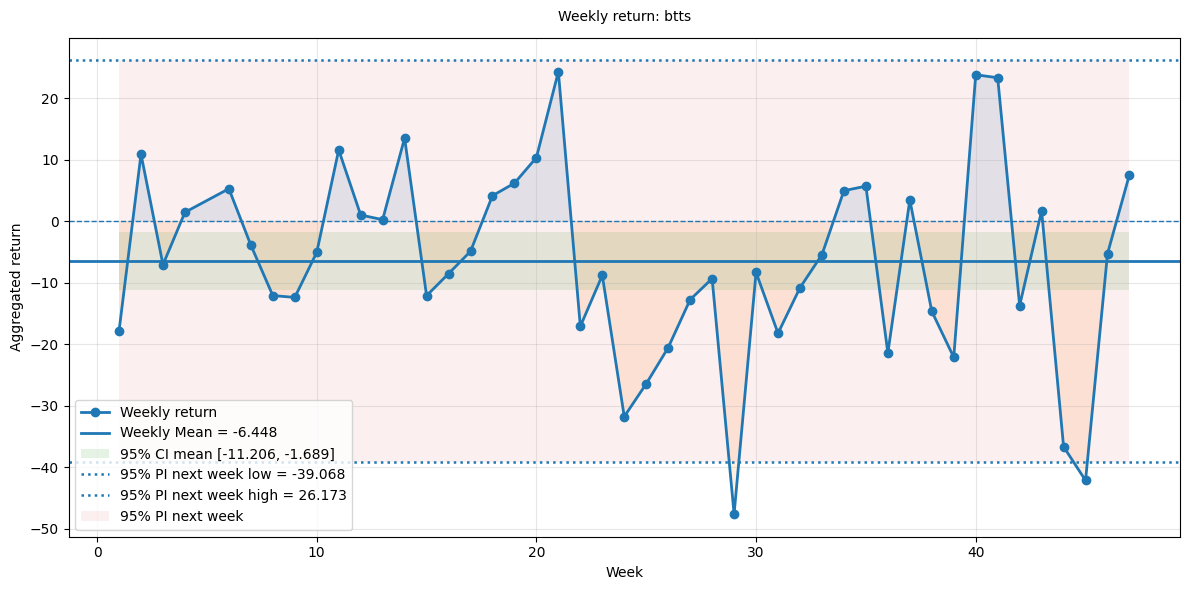

In [18]:
from utils import analyze_strategies
# Create the test binned dataframe
df_binned = df.copy()

for feat, step in feature_bins_map.items():
    df_binned[feat] = [round_to_step(x, step) for x in df_binned[feat]]

    if isinstance(step, int):
        df_binned[feat] = df_binned[feat].astype("Int64")

df_binned = df_binned.sort_values(by="time", ascending=False)
 
df_binned["strategy"] = target_col

weekly_return, stats = analyze_strategies(df_binned, strategies=[target_col], print_pi=True)

mask = get_mask(df_binned, study.best_trial.user_attrs)

df_filtered = df_binned[mask]